## Salary prediction simple linear Regression 

In [39]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
#Reading dataset
df=pd.read_csv('../../../datasets/Salary Data(SLR).csv')

In [41]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [43]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


C:\Users\premier\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


Text(-2.6805555555555483, 0.5, 'Salary')

<Figure size 1200x600 with 0 Axes>

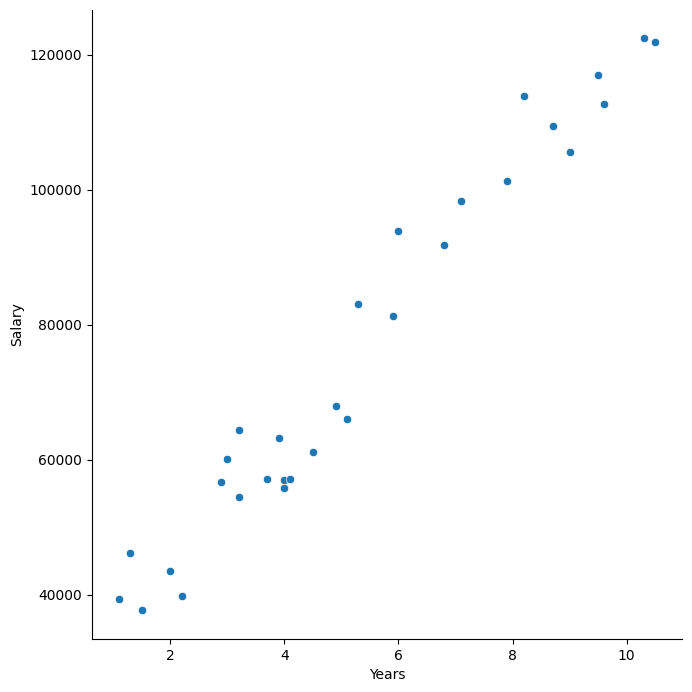

In [66]:
#Showing how the variables are scattered
plt.figure(figsize=(12,6))
sns.pairplot(df,x_vars=['YearsExperience'],y_vars=['Salary'],size=7,kind='scatter')
plt.xlabel('Years')
plt.ylabel('Salary')

<Axes: xlabel='Salary', ylabel='Count'>

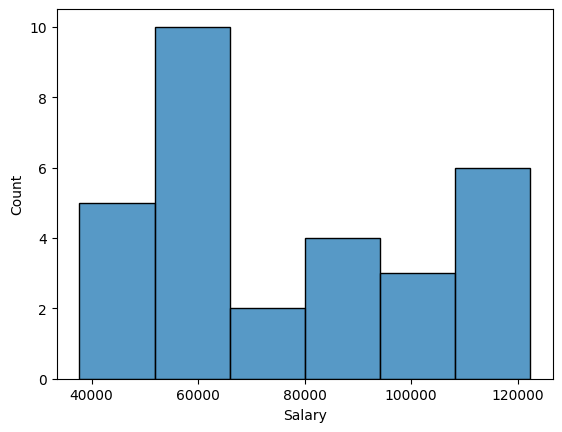

In [45]:
sns.histplot(df["Salary"])

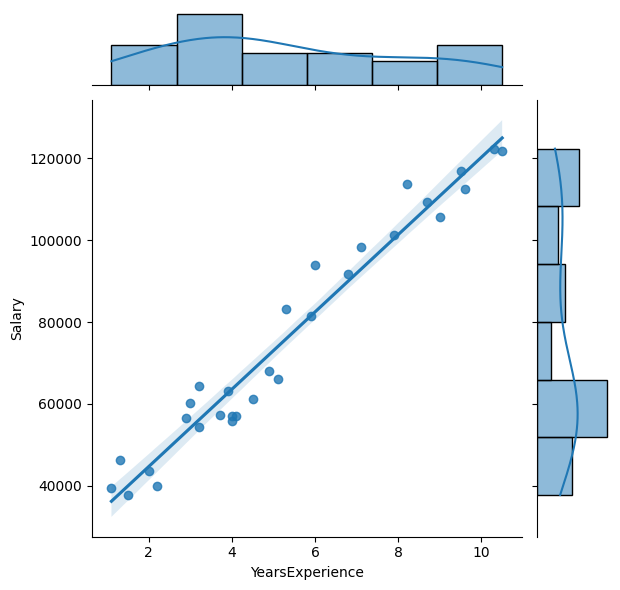

In [46]:
#Showing a regression line
sns.jointplot(x="YearsExperience", y="Salary", kind="reg", data=df)

<Axes: xlabel='YearsExperience', ylabel='Salary'>

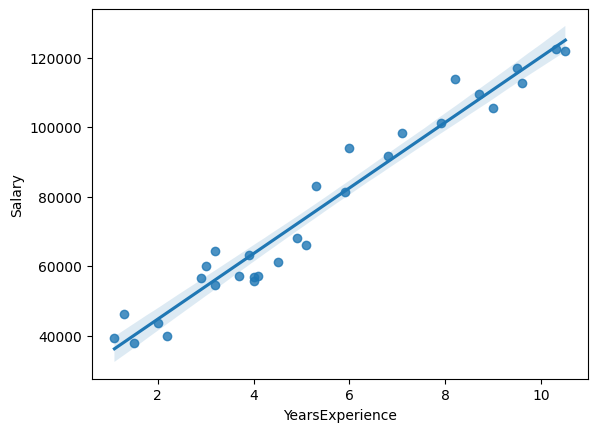

In [47]:
sns.regplot(x="YearsExperience", y="Salary", data=df)

In [48]:
#Checking for null values
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

Defining X data & Y data

In [49]:
X=df['YearsExperience']   # independent variable
Y=df['Salary']

Simple Linear Regression

In [50]:
#Importing segregating data from scikit learn
from sklearn.model_selection import train_test_split

In [51]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [52]:
#Splitting the data for train and test 
X_train,X_test,y_train,y_test = train_test_split(X,Y, train_size=0.7,random_state=42)

In [53]:
#Importing the model
from sklearn.linear_model import LinearRegression

In [54]:
print(X_train.shape)
print(type(X_train))

(21, 1)
<class 'pandas.core.frame.DataFrame'>


In [55]:
#Fitting data to the model
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
#Predicting the Salary for the test values
y_predict = lr.predict(X_test)
y_predict

array([115573.62288352,  71679.93878159, 102498.90847018,  75415.57147111,
        55803.4998511 ,  60473.04071301, 122110.98009019, 107168.44933209,
        63274.76523015])

Let,s check this with an example. Assume that an employee has 3.4 years of experience and we want to predict salary.


In [57]:
lr.predict([[3.4]])

C:\Users\premier\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([57671.31619586])

In [62]:
lr.predict([[10]])

C:\Users\premier\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([119309.25557305])

Text(0.5, 1.0, 'Actual vs. Predicted')

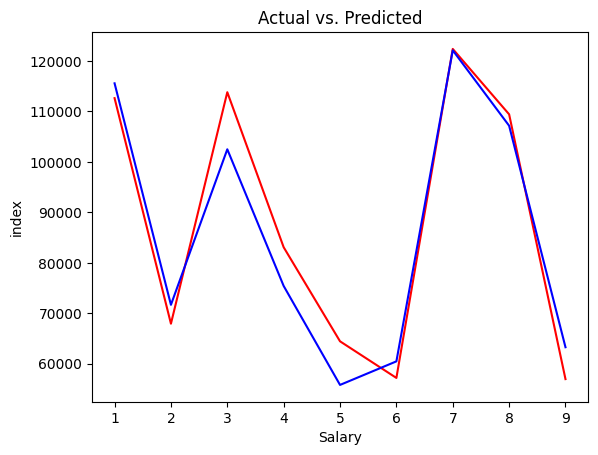

In [58]:
#Plotting the actual and predicted values
c = [i for i in range (1,len(y_test)+1,1)]
plt.plot(c,y_test,color='r',linestyle='-')
plt.plot(c,y_predict,color='b',linestyle='-')
plt.xlabel('Salary')
plt.ylabel('index')
plt.title('Actual vs. Predicted')

Text(0.5, 1.0, 'Error Value')

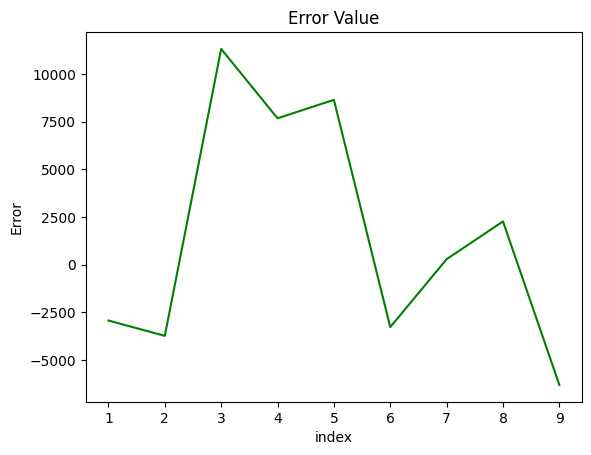

In [59]:
#Plotting the error
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_predict,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')

In [60]:
#Intercept and coeff of the line
print('Intercept of the model:',lr.intercept_)
print('Coefficient of the line:',lr.coef_)

Intercept of the model: 25918.438334893202
Coefficient of the line: [9339.08172382]


Then it is said to form a line with 
y = 25202.8 + 9731.2x